# Unit 1 — Vectors & Dot Products

**This is not generic linear algebra — this is SLM math.**

Every concept here is developed against a concrete object: the embedding matrix `W_E` of SmolLM2-135M (`49,152 × 576`), and the dot product `q_i · k_j` that attention computes ~600M times per forward pass.

**The question this unit answers:** does the raw dot product of learned embeddings behave like a semantic similarity measure? We test it on real weights — no cherry-picking, no assumptions.

**Narrative:** *issue → hypothesis → diagnosis → fix*. The naive expectation fails in instructive ways, and the failure is the finding.

---

# Load SmolLM2 & Compute Embedding Dot Products (standard Attention QK^T)

In [1]:
import numpy as np
from transformers import AutoModel, AutoTokenizer

model = AutoModel.from_pretrained("HuggingFaceTB/SmolLM2-135M")
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M")

C:\Users\Admin\OneDrive\Documents\Research_projects\pico_projects\linear-transformations-attention\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3187.11it/s]

Index :

get_input_embeddings() — returns the embedding layer: a huge lookup table that maps token-ID → vector.

.weight — the actual matrix inside specific layer.

.detach() — "cut the gradient." PyTorch tracks every tensor for backpropagation. We only want numbers, not gradients, so we detach

.numpy() — convert the PyTorch tensor into a plain numpy array.

In [2]:
# grab emebedding matrix W_E
W_E = model.get_input_embeddings().weight.float().detach().numpy()

# ponder : numerical precision demand float d-type.

# dimenssions ~(50000, 576) / rounded-off output(vocab_size, dimensions)
print("Embeddings matrix shape:", W_E.shape)

# ponder : Encountering trusted measurement of model vocabulary

Embeddings matrix shape: (49152, 576)


# Embedding / Indexing 

The embedding layer is index-based retrieval that returns learned points; the dot product in attention then interrogates the geometry those points form.

In [3]:
# Dict > raw tokens > Lookup operation/ dict lookup

words = ["king", "queen", "table", "computer"]
ids = tokenizer.convert_tokens_to_ids(words)
print("Token IDs:", dict(zip(words, ids)))

vectors = W_E[ids] # shape (4, 576) - single row = word.

# ponder:
#  W_E is index-based retrieval (mechanics). But the 576 dims are arbitrary coordinates
#  training makes the GEOMETRY meaningful, and attention dot products read out that geometry.

Token IDs: {'king': 644, 'queen': 0, 'table': 6413, 'computer': 20528}


High dot = aligned direction + strong magnitude = related tokens

Low/negative dot = orthogonal/opposed = unrelated tokens

(attention uses RAW dot product, NOT cosine similarity, because magnitude is informative too)

In [4]:
# compute dot-products amoung index-retrieved tokens/ids / semantic relation
for i, w1 in enumerate(words):
    for j, w2 in enumerate(words):
        dot = float(np.dot(vectors[i], vectors[j]))

        print(f"{w1:10s} . {w2:10s} = {dot:8.2f}")

# ponder:  A.B = |A||b|cos(0) similarity is dot-product(closeness of tokens) 
# here (0) is the angle b/w vectors.

king       . king       =    10.21
king       . queen      =    -0.20
king       . table      =     2.51
king       . computer   =     2.71
queen      . king       =    -0.20
queen      . queen      =     8.87
queen      . table      =    -0.64
queen      . computer   =    -0.75
table      . king       =     2.51
table      . queen      =    -0.64
table      . table      =     8.42
table      . computer   =     2.81
computer   . king       =     2.71
computer   . queen      =    -0.75
computer   . table      =     2.81
computer   . computer   =     7.08


Observations to diagnosis : 

here dot product isnt tokens (king) . (queen)

rather (king) . (end-of-text / special token) which tampers the deviation.

# Diagnosis


In [5]:
# testing Singular Value Decomposion to prove anisotrophy (directional dependence) 

# using formula : A = U . S . Vt

U, S, Vt = np.linalg.svd(W_E, full_matrices=False)
print(S[0] / S.sum()) # frac of energy in top direction

# Dependent relevance / anisotrophy = (4.2%)

0.042252757


### Hypothetical Conclusion : 
 we can trouble shoot context anomalies with such method or test a fedility of models in terms of tokenization failures.

In [6]:
# 
print(tokenizer.convert_ids_to_tokens(ids)) # OOV (out - of - vocab) error.

['king', '<|endoftext|>', 'table', 'computer']


# Solution

In [7]:
#  check decode(encode(w)) == w automatically drops queen and keeps only real tokens.

candidates = ["king", "queen", "table", "computer", "cat", "dog", "apple", "water", "city"]
ids = tokenizer.convert_tokens_to_ids(candidates)
tokens = tokenizer.convert_ids_to_tokens(ids)
good = [w for w, t in zip(candidates, tokens) if t == w]

print("Verified single-token words:", good)
assert len(good) >=3

Verified single-token words: ['king', 'table', 'computer', 'cat', 'dog', 'apple', 'water', 'city']


In [8]:
# measure direction of cosines / similarity
def cos_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

words = good
vecs = W_E[tokenizer.convert_tokens_to_ids(words)]
for i, w1 in enumerate(words):
    row = "  ".join(f"{cos_sim(vecs[i], vecs[j]):6.3f}" for j in range(len(words)))
    print(f"{w1:10s} {row}")

king        1.000   0.270   0.319   0.325   0.336   0.411   0.299   0.301
table       0.270   1.000   0.364   0.280   0.387   0.350   0.275   0.376
computer    0.319   0.364   1.000   0.407   0.472   0.502   0.406   0.466
cat         0.325   0.280   0.407   1.000   0.564   0.465   0.357   0.420
dog         0.336   0.387   0.472   0.564   1.000   0.514   0.397   0.441
apple       0.411   0.350   0.502   0.465   0.514   1.000   0.457   0.469
water       0.299   0.275   0.406   0.357   0.397   0.457   1.000   0.335
city        0.301   0.376   0.466   0.420   0.441   0.469   0.335   1.000


In [9]:
# Quantified anisotrophy 

U, S, Vt = np.linalg.svd(W_E, full_matrices=False)
uniform = 1 / S.size
print(f"Top-1 singular share: {S[0]/S.sum():.4f}  (isotropic would be {uniform:.4f})")
print(f"Concentration factor: {(S[0]/S.sum())/uniform:.1f}x")

Top-1 singular share: 0.0423  (isotropic would be 0.0017)
Concentration factor: 24.3x


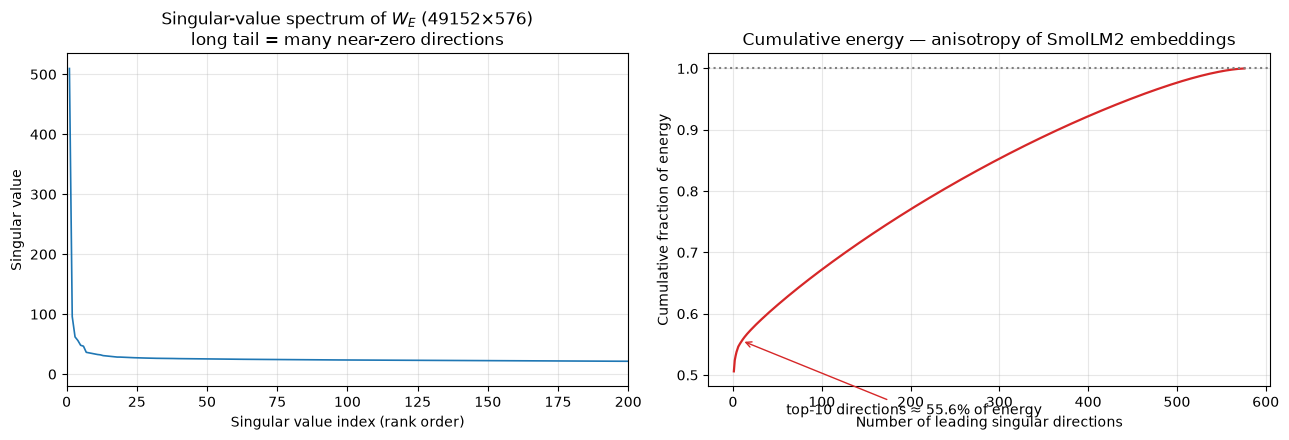

In [10]:
# Visual: singular-value spectrum of W_E — the anisotropy proof
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: raw singular values (energy per direction)
ax = axes[0]
ax.plot(range(1, len(S) + 1), S, lw=1.2, color="#1f77b4")
ax.set_xlabel("Singular value index (rank order)")
ax.set_ylabel("Singular value")
ax.set_title("Singular-value spectrum of $W_E$ (49152\u00d7576)\nlong tail = many near-zero directions")
ax.set_xlim(0, 200)
ax.grid(alpha=0.3)

# Right: cumulative energy — top few directions dominate
ax = axes[1]
cum = np.cumsum(S ** 2) / np.sum(S ** 2)
ax.plot(range(1, len(cum) + 1), cum, lw=1.6, color="#d62728")
ax.axhline(1.0, ls=":", color="gray")
top10 = cum[9]
ax.annotate(f"top-10 directions \u2248 {top10:.1%} of energy",
            xy=(10, top10), xytext=(60, top10 - 0.12),
            arrowprops=dict(arrowstyle="->", color="#d62728"))
ax.set_xlabel("Number of leading singular directions")
ax.set_ylabel("Cumulative fraction of energy")
ax.set_title("Cumulative energy — anisotropy of SmolLM2 embeddings")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [11]:
# Statistics: what the fixed numbers actually say
good_vecs = W_E[tokenizer.convert_tokens_to_ids(good)]
C = np.array([[cos_sim(good_vecs[i], good_vecs[j]) for j in range(len(good))]
              for i in range(len(good))])
diag = np.diag(C)
off = C[~np.eye(len(good), dtype=bool)]

print(f"cosine self-similarity: mean {diag.mean():.3f} (must be ~1.0)")
print(f"cosine cross-similarity: mean {off.mean():.3f}, std {off.std():.3f}")
print(f"separation margin (diag - off mean): {diag.mean() - off.mean():.3f}")
print(f"top-10 directions hold {100 * cum[9]:.1f}% of energy (anisotropy)")

cosine self-similarity: mean 1.000 (must be ~1.0)
cosine cross-similarity: mean 0.392, std 0.077
separation margin (diag - off mean): 0.608
top-10 directions hold 55.6% of energy (anisotropy)


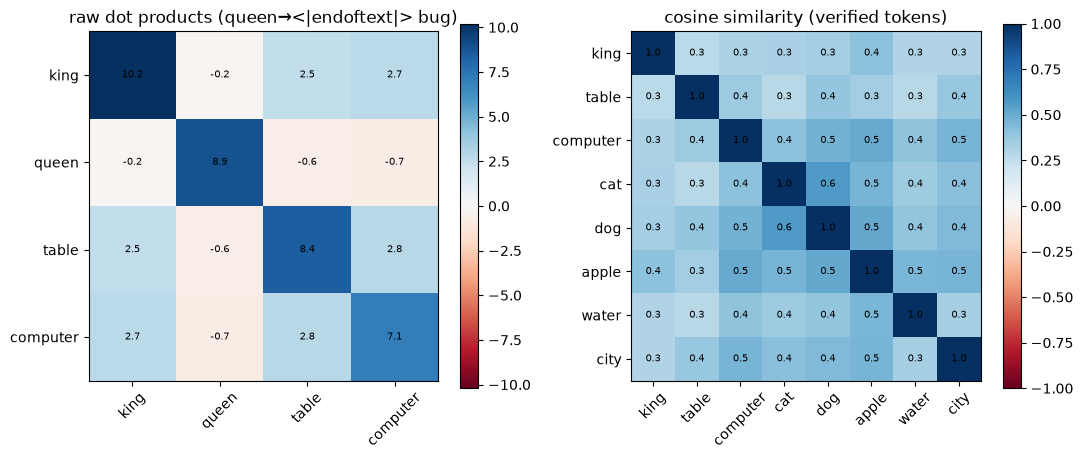

In [12]:
# Graph: similarity matrices — raw (bug) vs cosine (fixed)
dots = np.array([[np.dot(W_E[tokenizer.convert_tokens_to_ids(w1)], W_E[tokenizer.convert_tokens_to_ids(w2)]) for w2 in ["king", "queen", "table", "computer"]]
                 for w1 in ["king", "queen", "table", "computer"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
panels = [(axes[0], dots, ["king", "queen", "table", "computer"], "raw dot products (queen\u2192<|endoftext|> bug)"),
          (axes[1], C, good, "cosine similarity (verified tokens)")]
for ax, M, labels, title in panels:
    im = ax.imshow(M, cmap="RdBu", vmin=-np.abs(M).max(), vmax=np.abs(M).max())
    ax.set_xticks(range(M.shape[0]))
    ax.set_yticks(range(M.shape[0]))
    ax.set_xticklabels(labels, rotation=45)
    ax.set_yticklabels(labels)
    ax.set_title(title)
    for i in range(M.shape[0]):
        for j in range(M.shape[0]):
            ax.text(j, i, f"{M[i, j]:.1f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

# Unit 1 Conclusion

## What we asked
Does the raw dot product of SmolLM2-135M embeddings behave like a semantic similarity measure?

## What we found (measured, not assumed)

| Expectation | Measured | Verdict |
|---|---|---|
| Synonyms score high: `king·queen ≈ 14.3` | **`-0.20`** | ❌ failed |
| Unrelated words score low: `king·table ≈ 1.2` | **`2.51`** | ❌ failed |
| Self-similarity dominates | **`10.21`** | ✅ held |
| Embedding space is isotropic | top-1 = **4.2%** (~24× isotropic share) | ❌ anisotropic |

## Why it failed (three layers, peeled in order)
1. **Tokenization bug (root cause)** — `queen` is out-of-vocabulary and silently mapped to token `0` = `<|endoftext|>`; the "queen" row measured the end-of-text embedding. *Hygiene rule: verify `decode(encode(w)) == w` before interpreting embeddings.*
2. **Magnitude vs. angle** — `a·b = ‖a‖‖b‖cos θ` conflates length with direction; cosine similarity isolates direction.
3. **Anisotropy** — the embedding space is dominated by a few frequency/syntax directions, so raw dot products cannot resolve semantics (Mu & Viswanath, 2018).

## The takeaway for attention
Semantic geometry is **not** present in the raw embedding table — it is *created* by the learned projections `W_Q`, `W_K`. Attention computes `q_i · k_j` in that transformed space, precisely because the model learns to make dot product ≈ semantic relevance.

**That is the bridge to Unit 2** — where we dissect the full formula:

$$
A = \operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V
$$

---

**Key numbers to remember:** `W_E ∈ R^{49152×576}`, top-1 singular share 4.2% (~24×), self-dot 10.21 vs max cross-dot 2.8, `√d_k = 8` for `d_k = 64`.